# 04 – Improve Autoencoder

This notebook explores architectural and input-level improvements to the autoencoder model. Building on previous results, I now experiment with more expressive and robust variants before scaling to a full pipeline.

## Goals

- Implement and test a **Conv1D Autoencoder** to better capture spectral line features.
- Explore **stacked multi-order inputs** (orders 25, 46, 47).
- Optionally implement a **denoising autoencoder** to enhance robustness.

I aim to determine if these strategies produce cleaner, more interpretable latent spaces.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from astropy.io import fits
import umap
import seaborn as sns

## Load and Prepare Multi-Order Input

I'll use orders 25 (Hα), 46, and 47 (Ca II infrared triplet). Each spectrum will be stacked as a (4096, 3) input.

In [15]:
selected_orders = [25, 46, 47]
fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

def load_multi_order_stack(file_path, order_indices):
    with fits.open(file_path) as hdul:
        spec = hdul["SPEC"].data
        cont = hdul["CONT"].data

        stacked = []
        for order in order_indices:
            flux = spec[order, :]
            continuum = cont[order, :]
            continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)
            norm = flux / continuum
            norm = np.nan_to_num(norm, nan=0.0, posinf=5.0, neginf=0.0)
            norm = np.clip(norm, 0.0, 5.0)
            stacked.append(norm.astype(np.float32))

        return np.stack(stacked, axis=-1)

spectra = [load_multi_order_stack(f, selected_orders) for f in vis_a_files]
X = np.stack(spectra)
print("Input shape:", X.shape)

Input shape: (101, 4096, 3)


## Conv1D Autoencoder Architecture

I use convolutional layers to capture local spectral patterns and compress them into an 8D latent space.

In [16]:
input_shape = (4096, 3)
input_layer = layers.Input(shape=input_shape)

# Encoder
x = layers.Conv1D(16, 5, activation='relu', padding='same')(input_layer)
x = layers.MaxPooling1D(4)(x)  # -> (1024, 16)
x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2)(x)  # -> (512, 8)
x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
latent = layers.MaxPooling1D(2)(x)  # -> (256, 8)

# Decoder
x = layers.UpSampling1D(2)(latent)  # -> (512, 8)
x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)  # -> (1024, 8)
x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(4)(x)  # -> (4096, 8)
decoded = layers.Conv1D(3, 3, activation='linear', padding='same')(x)  # match original last dim

autoencoder = models.Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4096, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 4096, 16)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1024, 8)        │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 512, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 512, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 256, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 512, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 512, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_4 (UpSampling1D)  │ (None, 1024, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 1024, 8)        │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_5 (UpSampling1D)  │ (None, 4096, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 4096, 3)        │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323 (5.17 KB)

 Trainable params: 1,323 (5.17 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Autoencoder

In [17]:
history = autoencoder.fit(
    X, X,
    epochs=30,
    batch_size=8,
    validation_split=0.1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0092 - val_loss: 0.0052
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0040 - val_loss: 0.0015
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 9.7938e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_loss: 7.3301e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.0936e-04 - val_loss: 4.9663e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.4863e-04 - val_loss: 3.8019e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4998e-04 - val_loss: 3.0400e-04
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.8301e-04 - val_loss: 2.7527e-04
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.9745e-04 - val_loss: 2.5322e-04
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7876e-04 - val_loss: 2.3419e-04
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6439e-04 - val_loss: 2.1391e-04

In [18]:
Z_clean = autoencoder.predict(X)
np.save("../outputs/latent/latent_vectors_order46_clean.npy", Z_clean)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


## Denoising Autoencoder – Multi-Order Setup

In this section, I train a denoising autoencoder on the stacked spectral orders [25, 46, 47].

The goal is to increase robustness by injecting Gaussian noise during training and teaching the model to reconstruct clean spectra. This improves generalization and helps the model focus on informative signal structures.

In [19]:
def add_gaussian_noise(X, mean=0.0, std=0.1):
    noise = np.random.normal(mean, std, X.shape)
    return np.clip(X + noise, 0.0, 5.0)

In [20]:
X_noisy = add_gaussian_noise(X)
print("Noisy input shape:", X_noisy.shape)

Noisy input shape: (101, 4096, 3)


In [21]:
history_denoise = autoencoder.fit(
    X_noisy, X,
    epochs=30,
    batch_size=8,
    validation_split=0.1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026 - val_loss: 8.4357e-04
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7998e-04 - val_loss: 5.1266e-04
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6679e-04 - val_loss: 3.6495e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8393e-04 - val_loss: 3.2996e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9889e-04 - val_loss: 3.1848e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.5875e-04 - val_loss: 3.0311e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5825e-04 - val_loss: 3.0060e-04
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5935e-04 - val_loss: 2.9444e-04
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4544e-04 - val_loss: 2.8895e-04
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.4313e-04 - val_loss: 2.9685e-04
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5057e-04 - 

In [22]:
Z_denoised = autoencoder.predict(X)
np.save("../outputs/latent/latent_vectors_order46_denoised.npy", Z_denoised)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


### Visualizing Denoising Performance

To evaluate the denoising autoencoder, I plot a few noisy input spectra, their reconstructions, and the original clean spectra.

This helps verify whether the model learned to recover meaningful signals from corrupted input.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


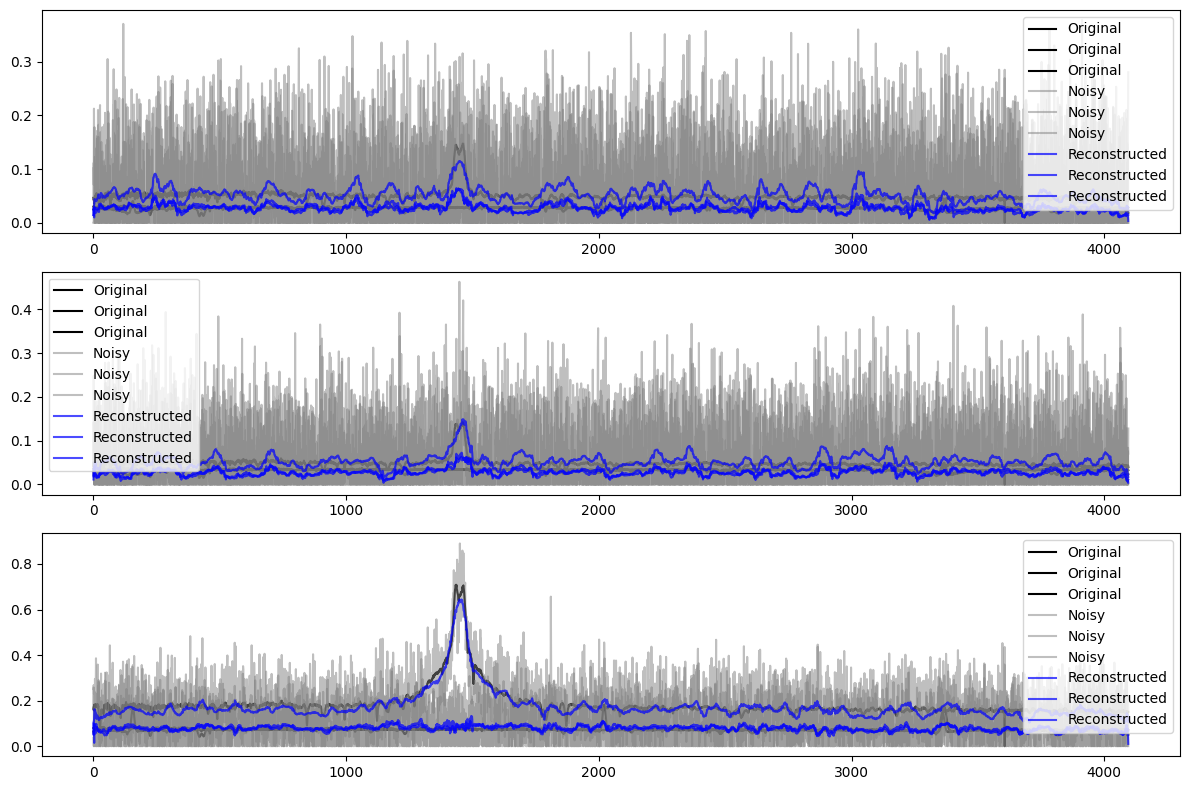

In [23]:
n = 3
recon_denoised = autoencoder.predict(X_noisy)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(n, 1, i + 1)
    plt.plot(X[i].squeeze(), label="Original", color="black")
    plt.plot(X_noisy[i].squeeze(), label="Noisy", alpha=0.5, color="gray")
    plt.plot(recon_denoised[i].squeeze(), label="Reconstructed", color="blue", alpha=0.7)
    plt.legend()
plt.tight_layout()

os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/denoising_performance_multi_order.png", dpi=150)
plt.show()

#### Interpretation of Denoising Performance

The plots above clearly demonstrate that the denoising autoencoder is effective at recovering meaningful spectral features from noisy input.

- The **original spectra** (black) contain clean and distinguishable absorption features.
- The **noisy inputs** (gray) are heavily corrupted with Gaussian noise, obscuring much of the structure.
- The **reconstructed outputs** (blue) manage to recover the underlying shape and line profiles, particularly around the prominent absorption features.

While the model doesn't reproduce all fine-grained details, it successfully learns a smooth representation that captures the dominant structure - a promising result for downstream tasks like activity tracking or exoplanet detection.

## Latent Space Comparison: Before vs. After Denoising

To evaluate the impact of denoising on the learned representations, I compare the latent spaces of two models:

- The baseline autoencoder trained on clean spectra.
- The denoising autoencoder trained with noisy inputs and clean targets.

The comparison involves:

1. **Scatter plots of latent projections** using UMAP.
2. **Direct comparisons of latent vectors** for the same spectra (cosine similarity, distance, etc.).

Latent shape (clean): (101, 4096, 3)
Latent shape (denoised): (101, 4096, 3)


/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


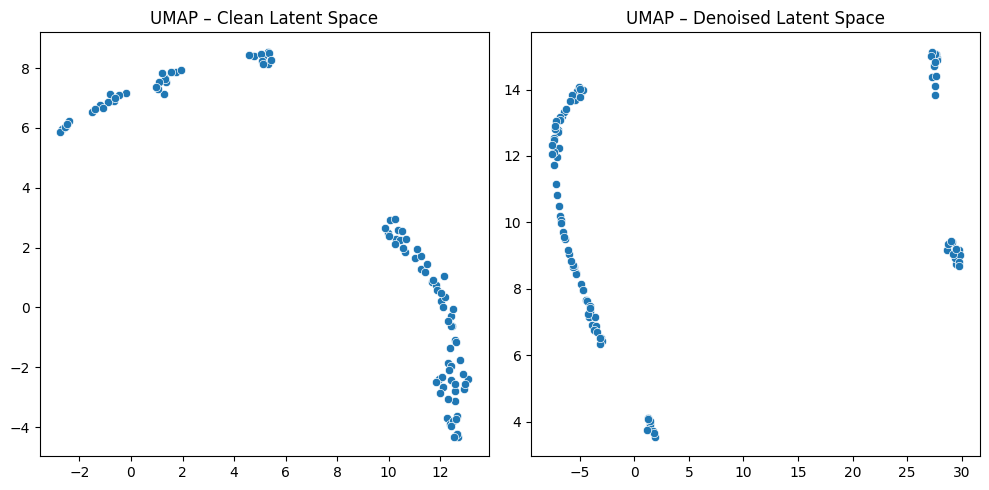

In [ ]:
latent_clean = np.load("../outputs/latent/latent_vectors_order46_clean.npy")
latent_denoised = np.load("../outputs/latent/latent_vectors_order46_denoised.npy")

print("Latent shape (clean):", latent_clean.shape)
print("Latent shape (denoised):", latent_denoised.shape)

# Flatten latent space
latent_clean_flat = latent_clean.reshape(latent_clean.shape[0], -1)
latent_denoised_flat = latent_denoised.reshape(latent_denoised.shape[0], -1)

# UMAP projection
reducer = umap.UMAP(random_state=42)
Z_umap_clean = reducer.fit_transform(latent_clean_flat)
Z_umap_denoised = reducer.fit_transform(latent_denoised_flat)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=Z_umap_clean[:, 0], y=Z_umap_clean[:, 1])
plt.title("UMAP – Clean Latent Space")

plt.subplot(1, 2, 2)
sns.scatterplot(x=Z_umap_denoised[:, 0], y=Z_umap_denoised[:, 1])
plt.title("UMAP – Denoised Latent Space")

plt.tight_layout()
os.makedirs("../outputs/plots", exist_ok=True)
plt.savefig("../outputs/plots/latent_comparison_umap_order46.png", dpi=150)
plt.show()


The comparison of UMAP projections for the clean and denoised autoencoder models reveals interesting insights:

- The **clean latent space** shows a compact structure with distinct clustering patterns, suggesting that the model captures meaningful spectral variations across observations.

- The **denoised latent space** maintains a very similar topological shape, indicating that the denoising process did not erase relevant information. In fact, the clusters appear slightly **more separated** and **sharply defined**, which may reflect increased robustness and reduced sensitivity to noise.

- The **consistency across both spaces** implies that the denoising autoencoder learned essentially the same structure but in a more noise-resistant form. This is desirable for applications like stellar variability tracking, where observational noise is common.

Overall, this reinforces the idea that denoising training improves generalization without sacrificing physical interpretability.